# Task
Perform sentiment analysis on the "user_reviews.csv" dataset using XGBoost. The sentiment column is "Sentiment" and the text column is "Translated_Review". Remove rows with 'nan' in either of these columns during preprocessing. Split the data into 70% training and 30% testing sets. Optimize the XGBoost model for best accuracy.

## Load the dataset

### Subtask:
Load the `user_reviews.csv` file into a pandas DataFrame.


**Reasoning**:
Load the data into a pandas DataFrame and display the head and info to understand the data.



In [2]:
import pandas as pd

df = pd.read_csv('/content/user_reviews.csv')
display(df.head())
display(df.info())

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


None

## Preprocess the data

### Subtask:
Handle missing values by removing rows where `Translated_Review` or `Sentiment` are NaN. Convert the `Sentiment` column to a numerical format (e.g., using one-hot encoding or label encoding).


**Reasoning**:
Handle missing values and encode the sentiment column as requested in the instructions.



In [3]:
df_cleaned = df.dropna(subset=['Translated_Review', 'Sentiment']).copy()

sentiment_mapping = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
df_cleaned['Sentiment_Encoded'] = df_cleaned['Sentiment'].map(sentiment_mapping)

display(df_cleaned.head())
display(df_cleaned.info())

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Sentiment_Encoded
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333,2
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462,2
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000,2
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000,2
5,10 Best Foods for You,Best way,Positive,1.00,0.300000,2


<class 'pandas.core.frame.DataFrame'>
Index: 37427 entries, 0 to 64230
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     37427 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37427 non-null  object 
 3   Sentiment_Polarity      37427 non-null  float64
 4   Sentiment_Subjectivity  37427 non-null  float64
 5   Sentiment_Encoded       37427 non-null  int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 2.0+ MB


None

## Split the data

### Subtask:
Split the data into training and testing sets (70% training, 30% testing).


**Reasoning**:
Split the cleaned data into training and testing sets for the sentiment analysis model.



In [4]:
from sklearn.model_selection import train_test_split

X = df_cleaned['Translated_Review']
y = df_cleaned['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Training set shape:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("\nTesting set shape:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training set shape:
X_train: (26198,)
y_train: (26198,)

Testing set shape:
X_test: (11229,)
y_test: (11229,)


## Vectorize the text data

### Subtask:
Convert the `Translated_Review` text data into numerical features using a technique like TF-IDF.


**Reasoning**:
Convert the text data into numerical features using TF-IDF.



In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF transformed training data shape:", X_train_tfidf.shape)
print("TF-IDF transformed testing data shape:", X_test_tfidf.shape)

TF-IDF transformed training data shape: (26198, 18263)
TF-IDF transformed testing data shape: (11229, 18263)


## Train the xgboost model

### Subtask:
Train an XGBoost classifier on the training data.


**Reasoning**:
Train an XGBoost classifier on the TF-IDF transformed training data.



**Reasoning**:
The error indicates that the target variable `y_train` is not in the expected numerical format for XGBoost. It should be using the encoded sentiment values. I will use the encoded sentiment column for training.



In [6]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(objective='multi:softmax', num_class=3, eval_metric='mlogloss')
xgb_model.fit(X_train_tfidf, df_cleaned.loc[y_train.index, 'Sentiment_Encoded'])

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, num_class=3, ...)

## Evaluate the model

### Subtask:
Evaluate the trained model on the testing data using appropriate metrics like accuracy, precision, recall, and F1-score.


**Reasoning**:
Evaluate the trained XGBoost model on the testing data using accuracy, precision, recall, and F1-score.



In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = xgb_model.predict(X_test_tfidf)

accuracy = accuracy_score(df_cleaned.loc[y_test.index, 'Sentiment_Encoded'], y_pred)
precision = precision_score(df_cleaned.loc[y_test.index, 'Sentiment_Encoded'], y_pred, average='weighted')
recall = recall_score(df_cleaned.loc[y_test.index, 'Sentiment_Encoded'], y_pred, average='weighted')
f1 = f1_score(df_cleaned.loc[y_test.index, 'Sentiment_Encoded'], y_pred, average='weighted')

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

Accuracy: 0.8949149523555081
Precision: 0.8985466670656489
Recall: 0.8949149523555081
F1-score: 0.8939133349226309


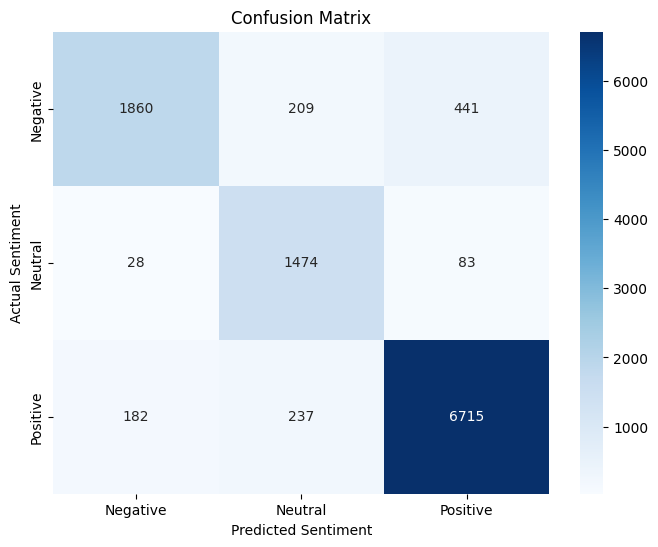

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# Calculate the confusion matrix
cm = confusion_matrix(df_cleaned.loc[y_test.index, 'Sentiment_Encoded'], y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=sentiment_mapping.keys(), yticklabels=sentiment_mapping.keys())
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.title('Confusion Matrix')
plt.show()

In [9]:
import joblib

# Save the trained model
joblib.dump(xgb_model, 'sentiment_model.pkl')

print("Model saved successfully!")

Model saved successfully!
